<a href="https://colab.research.google.com/github/AHMADAMJAD0/Pytorch/blob/main/ANN_Fasion_mnist_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Workflow**
we will complete the NN training model in 3 main steps

1 **Dataloader object**

2 **Training loop**

3 **Evaluatuon**

In [57]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset , DataLoader
import torch.optim as optim
from sklearn.model_selection import train_test_split

In [58]:
torch.manual_seed(42)

In [59]:
df = pd.read_csv("/content/fmnist_small.csv")

In [60]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


In [61]:
df.shape

(6000, 785)

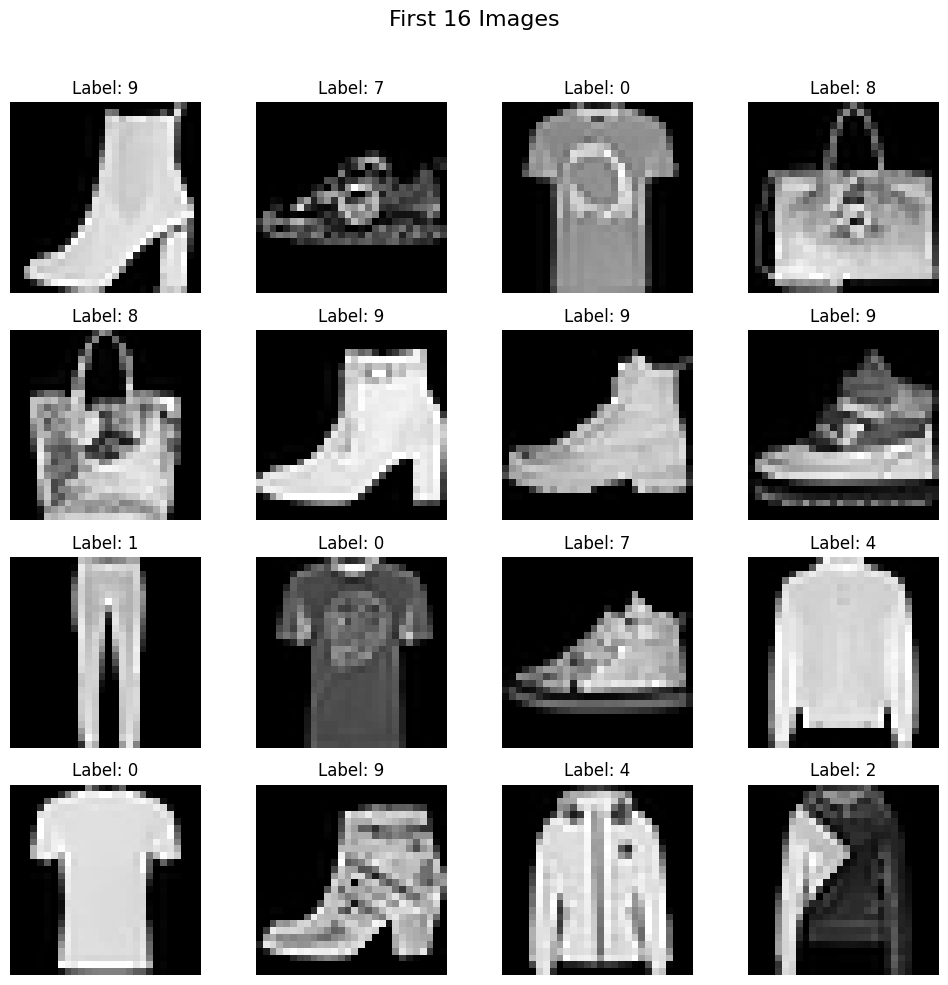

In [62]:
import matplotlib.pyplot as plt

# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))

# Add one main title for the whole figure
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):

    # Select image pixels from row i
    # df.iloc[i, 1:] means:
    # row i, all columns except the first column
    img = df.iloc[i, 1:].values.reshape(28, 28)

    # Display the image in grayscale
    ax.imshow(img, cmap="gray")

    # Remove x-axis and y-axis
    ax.axis("off")

    # Show the label as title
    ax.set_title(f"Label: {df.iloc[i, 0]}")

# Adjust layout so the main title does not overlap with images
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Display the plot
plt.show()

In [63]:
# train test split
x = df.iloc[: , 1:]
y = df.iloc[: , 0]



In [64]:


x_train, y_train, x_test, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [65]:
# scaling the features
x_train = x_train/255.0
x_test = x_test/255.0

In [66]:
x_train

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
3897,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
5628,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.003922,...,0.356863,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
1756,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
2346,0.0,0.0,0.0,0.0,0.0,0.003922,0.000000,0.000000,0.0,0.000000,...,0.003922,0.000000,0.000000,0.000000,0.000000,0.254902,0.090196,0.000000,0.0,0.0
2996,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.262745,...,0.533333,0.470588,0.286275,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
5191,0.0,0.0,0.0,0.0,0.0,0.000000,0.003922,0.000000,0.0,0.200000,...,0.000000,0.000000,0.003922,0.000000,0.031373,0.258824,0.000000,0.000000,0.0,0.0
5226,0.0,0.0,0.0,0.0,0.0,0.000000,0.011765,0.003922,0.0,0.000000,...,0.439216,0.474510,0.474510,0.027451,0.000000,0.003922,0.000000,0.000000,0.0,0.0
5390,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0


In [77]:
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# 1. Separate features and labels
# First column is label
# Remaining columns are image pixels
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

# 2. Normalize pixel values
X = X / 255.0

# 3. Correct train-test split order
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Check shapes
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (4800, 784)
y_train shape: (4800,)
x_test shape: (1200, 784)
y_test shape: (1200,)


In [78]:

# # creat customdataset class
# class CustomDataset(Dataset):
#   def __init__(self , features , labels):
#     self.features = torch.tensor(features , dtype= torch.float32)
#     self.labels = torch.tensor(labels , dtype= torch.float32)
#   def __len__(self):
#     return len(self.features)

#   def __getitem__(self, index):
#     return self.features[index] , self.labels[index]


import torch
from torch.utils.data import Dataset

class CustomDataset(Dataset):
  def __init__(self, features, labels):

    # Convert pandas DataFrame/Series to NumPy array
    if hasattr(features, "to_numpy"):
      features = features.to_numpy()

    if hasattr(labels, "to_numpy"):
      labels = labels.to_numpy()

    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]





In [79]:
# create train dataset object
train_dataset = CustomDataset(x_train , y_train)


In [80]:
len(train_dataset)

4800

In [81]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [82]:
# creat test dataset object
test_dataset = CustomDataset(x_test , y_test)

In [83]:
from numpy.random import shuffle
# create train and test loader
train_loader = DataLoader(train_dataset , batch_size = 32 , shuffle = True )
test_loader = DataLoader(test_dataset , batch_size = 32 , shuffle = True )

#here we completed the dataloader steps

we are going to start 2 step

# Training loop


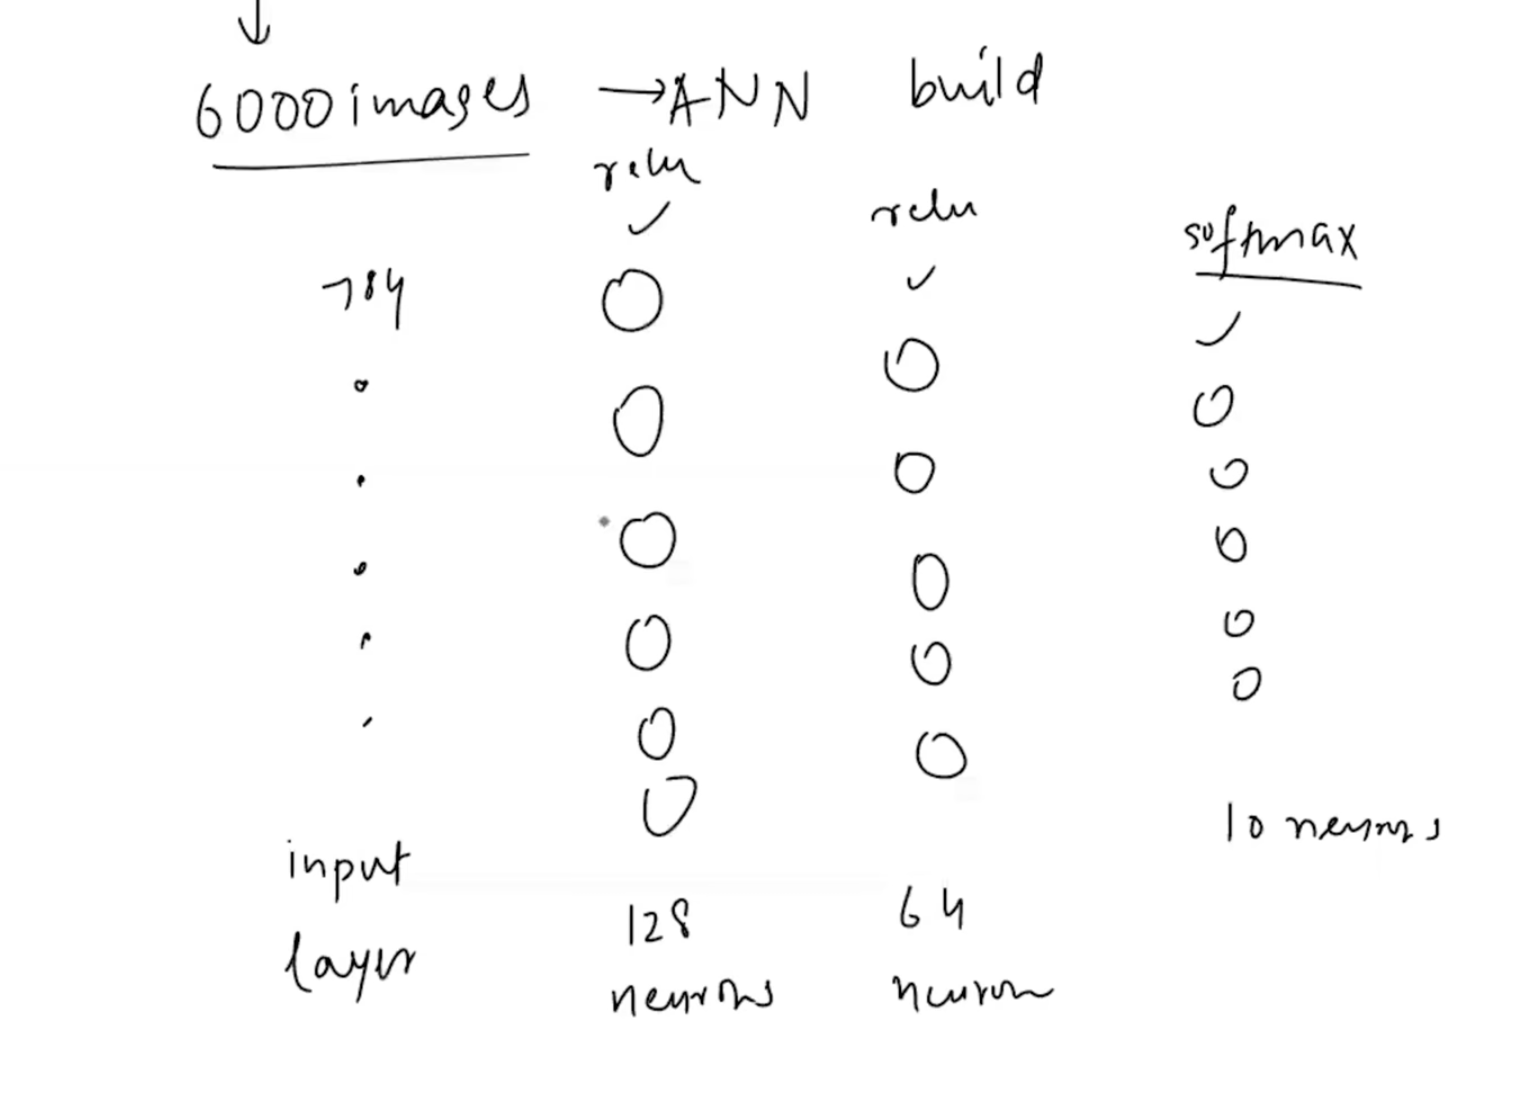

In [84]:
# define NN class
class MyNN(nn.Module):
  def __init__(self , num_features):

    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features ,128),
        nn.ReLU(),
        nn.Linear(128 , 64),
        nn.ReLU(),
        nn.Linear(64 , 10)

    )
  def forward(self , x):
    return self.model(x)

In [85]:
# set learning rate and epoch

epochs = 100
learning_rate = 0.1

In [86]:
# instatiate the model
model = MyNN(x_train.shape[1])


# loss function

criterion = nn.CrossEntropyLoss()


# optimizer

optimizer = optim.SGD(model.parameters() , lr = learning_rate)

In [87]:
# Training loop
for epoch in range(epochs):

    # Reset total loss at the start of each epoch
    total_epoch_loss = 0

    for batch_features, batch_labels in train_loader:

        # 1. Forward pass
        outputs = model(batch_features)

        # 2. Calculate loss
        loss = criterion(outputs, batch_labels)

        # 3. Clear old gradients
        optimizer.zero_grad()

        # 4. Backward pass
        loss.backward()

        # 5. Update parameters
        optimizer.step()

        # 6. Add current batch loss to total epoch loss
        total_epoch_loss = total_epoch_loss + loss.item()

    # 7. Calculate average loss after all batches are done
    avg_loss = total_epoch_loss / len(train_loader)

    # 8. Print loss for this epoch
    print(f"Epoch: {epoch + 1}, Loss: {avg_loss}")

Epoch: 1, Loss: 1.366908957163493
Epoch: 2, Loss: 0.7868862154086431
Epoch: 3, Loss: 0.6612437705198924
Epoch: 4, Loss: 0.5921929277976354
Epoch: 5, Loss: 0.5361840970317523
Epoch: 6, Loss: 0.5046798941493035
Epoch: 7, Loss: 0.4875925116737684
Epoch: 8, Loss: 0.45172640681266785
Epoch: 9, Loss: 0.4269793491065502
Epoch: 10, Loss: 0.4106637156506379
Epoch: 11, Loss: 0.38549119492371875
Epoch: 12, Loss: 0.37236822123328844
Epoch: 13, Loss: 0.3614173839489619
Epoch: 14, Loss: 0.3433729842305183
Epoch: 15, Loss: 0.3161926350990931
Epoch: 16, Loss: 0.3139029045154651
Epoch: 17, Loss: 0.3037796687086423
Epoch: 18, Loss: 0.2915485258897146
Epoch: 19, Loss: 0.2761858151977261
Epoch: 20, Loss: 0.2735417686402798
Epoch: 21, Loss: 0.2644840948532025
Epoch: 22, Loss: 0.25753391849497953
Epoch: 23, Loss: 0.2566365112364292
Epoch: 24, Loss: 0.2367132013787826
Epoch: 25, Loss: 0.2323358156035344
Epoch: 26, Loss: 0.2391073310871919
Epoch: 27, Loss: 0.22257311751445136
Epoch: 28, Loss: 0.21559111898144

In [88]:
print("done")

done


In [89]:
# set model to eval mode
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [91]:
# evalution code
